# NB10 — PySR / GP Symbolic Regression (30-Run Marathon)

**Project:** Evolutionary Computation for Sepsis Mortality Prediction

**Input:**
- `data/processed/features_curated.parquet`
- `data/processed/split_random.csv` (70/10/20 train/val/test)
- `data/processed/gp_terminal_set.csv`
- `data/processed/baseline_test_predictions.csv`
- `data/processed/apache4_predictions.csv`
- `results/shared/tables/baseline_test_metrics.csv`

**Output:**
- `results/v2_bce/gp_runs/run_00_pareto.csv` … `run_29_pareto.csv` — per-run Pareto fronts (val metrics)
- `results/v2_bce/gp_runs/run_00_model.pkl` … `run_29_model.pkl` — per-run pickled models
- `results/v2_bce/tables/gp_30runs_summary.csv` — 30-row merged summary
- `data/processed/gp_predictions_v2_bce.csv` — canonical test-set predictions
- `results/v2_bce/tables/NB10_gp_pareto.csv` — canonical run Pareto front
- `results/v2_bce/tables/NB10_gp_test_metrics.csv` — GP + all baselines
- `results/v2_bce/figures/NB10_gp_calibration.pdf/.png`

---

### Purpose
Evolve compact, interpretable symbolic mortality risk scores using PySR genetic
programming on the 26-feature GP_TERMINALS set (NB09). This is the core novelty of
the thesis (RQ1, Contribution C1).

**Reproducibility design.** PySR is stochastic — results vary across random seeds.
GP is therefore run 30 independent times (seeds 0–29). Each run saves its full
Pareto front and pickled model to disk. The canonical expression is selected by
validation-set fitness from the best single run, and final metrics are reported on
the held-out test set. Statistical tests characterise performance distribution across
the 30 runs.

### Runtime warning
- **Cell 1 (Julia compilation):** First import triggers Julia JIT compilation. Expect
  **5–10 minutes of silence** on first run — do not interrupt.
- **Cell 2 (30-run marathon):** `niterations=6000`, `populations=30`, 30 seeds.
  Observed runtime: **~65–70 hours total** (~131 min per run under BCE loss). The loop
  saves after each run and skips already-completed runs — safe to interrupt and resume.

### Design decisions

| Parameter | Value | Rationale |
|---|---|---|
| Loss | Custom BCE on sigmoid(pred) vs binary target, logit space | Standard binary cross-entropy evaluated in logit space. Replaces the original MSE-on-binary-target design, which permitted unbounded raw outputs requiring post-hoc clipping that could mask true miscalibration. A first candidate fix (`LogitDistLoss()`) was rejected after pilot testing confirmed it is a distance-regression loss, not cross-entropy (see `NB10_pilot_logitdistloss.ipynb`). The custom BCE loss was pilot-validated against 4 diagnostic criteria and selected over a Sigmoid-MSE alternative (see `NB10_pilot_custom_loss.ipynb`). `gp.predict()` returns the raw logit; `sigmoid()` (defined in Cell 1) converts to probability — never `np.clip`. |
| Expression selection | Val-set fitness = AUROC − 0.5 × ECE | Selection uses the 10% validation set (n=1,117) — never the test set |
| niterations | 6,000 | Sufficient search depth; PySR early-stops on Pareto convergence |
| populations | 30 | As specified |
| maxsize | 24 | Controls maximum expression complexity |
| parsimony | 0.001 | Penalises complexity on training loss |

### Function set
- **Binary:** `+`, `−`, `×`, `÷` (protected), `max`, `min`
- **Unary:** `log` (protected), `sqrt` (protected), `exp` (clipped), `abs`

---

## Cell 1 — Load data and prepare GP arrays

**Plan.** Load all inputs from disk. Extract the 26 GP_TERMINALS columns for
train (70%), val (10%), and test (20%) sets. The val set is used exclusively for
Pareto expression selection in Cell 2 — it is never seen during evolution.
Import `src.metrics` shared utilities



In [2]:
%matplotlib inline
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import json, pickle, time, sys, warnings
warnings.filterwarnings("ignore")

_nb_dir   = Path().resolve()
PROJECT   = _nb_dir.parent if _nb_dir.name == "notebooks" else _nb_dir
DATA_PROC = PROJECT / "data" / "processed"

# ── Versioned results layout: results/{shared,v1_mse,v2_bce}/{tables,figures,gp_runs,...} ──
# v1_mse = frozen baseline (MSE-on-binary loss, niterations=6000x30 seeds, pre-2026-06-25).
# v2_bce = current run (custom BCE loss in logit space, pilot-validated in
#          NB10_pilot_custom_loss.ipynb). shared/ = NB01-09 + baseline outputs,
#          independent of the GP loss function — never duplicated per version.
RESULTS_VERSION = "v2_bce"
SHARED    = PROJECT / "results" / "shared"
TABLES    = PROJECT / "results" / RESULTS_VERSION / "tables"
FIGURES   = PROJECT / "results" / RESULTS_VERSION / "figures"
RUNS_DIR  = PROJECT / "results" / RESULTS_VERSION / "gp_runs"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

# Custom BCE loss for PySR — standard binary cross-entropy of sigmoid(pred) vs the
# binary target, evaluated in logit space. Replaces MSE-on-binary-target (v1_mse) and
# the rejected LogitDistLoss() built-in (confirmed via pilot + Julia docs to be a
# distance-regression loss, not cross-entropy — see NB10_pilot_logitdistloss.ipynb).
# Pilot-validated 2026-06-25 (NB10_pilot_custom_loss.ipynb): passes all 4 supervisor
# diagnostic checks; selected over the Sigmoid-MSE alternative on the project's
# standard fitness metric AUROC - 0.5*ECE (0.738 vs 0.709).
# FOOTNOTE: this string is verbatim identical to the Julia loss specified by the
# supervisor (Teams message, 2026-06-25, "Pilot A / BCE" spec) — char-for-char match
# confirmed. Defined once here and referenced as BCE_LOSS everywhere it's needed
# (this notebook's Cell 2, and NB11_repro_runs.ipynb) rather than re-inlined, so a
# future fix only needs to happen in one place.
BCE_LOSS = ("((pred, tgt) -> let p = 1.0/(1.0+exp(-pred)); "
            "p = clamp(p, 1e-10, 1.0-1e-10); "
            "-(tgt*log(p) + (1.0-tgt)*log(1.0-p)) end)")

# ── Shared metric utilities (ECE consistent last-bin boundary) ────────────────
if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))
from src.metrics import compute_ece, compute_metrics, calibration_bins

# ── Primary inputs ────────────────────────────────────────────────────────────
feat    = pd.read_parquet(DATA_PROC / "features_curated.parquet")
split   = pd.read_csv(DATA_PROC / "split_random.csv")
with open(DATA_PROC / "feature_config.json") as f:
    cfg = json.load(f)
GP_TERMINALS = cfg["GP_TERMINALS"]

# ── Baseline inputs (for calibration comparison in Cell 6) ───────────────────
# LR/RF/XGB/Platt baselines do not depend on the GP loss function — read from shared/.
bl_preds_df  = pd.read_csv(DATA_PROC / "baseline_test_predictions.csv")
apache_preds = pd.read_csv(DATA_PROC / "apache4_predictions.csv")
bl_metrics   = pd.read_csv(SHARED / "tables" / "baseline_test_metrics.csv")

# ── Train / val / test arrays ─────────────────────────────────────────────────
feat = feat.merge(split[["patientunitstayid", "split"]], on="patientunitstayid")
train_df = feat[feat["split"] == "train"].reset_index(drop=True)
val_df   = feat[feat["split"] == "val"].reset_index(drop=True)
test_df  = feat[feat["split"] == "test"].reset_index(drop=True)

X_train_gp = train_df[GP_TERMINALS].copy()
y_train    = train_df["hospital_mortality"].to_numpy(dtype=np.float64)
X_val_gp   = val_df[GP_TERMINALS].copy()
y_val      = val_df["hospital_mortality"].to_numpy(dtype=np.float64)
X_test_gp  = test_df[GP_TERMINALS].copy()
y_test     = test_df["hospital_mortality"].to_numpy(dtype=np.float64)

print(f"Results version : {RESULTS_VERSION}  (custom BCE loss, logit-space)")
print(f"GP_TERMINALS : {len(GP_TERMINALS)} features")
print(f"Train        : {len(X_train_gp):,} patients | {int(y_train.sum())} deaths ({y_train.mean()*100:.2f}%)")
print(f"Val          : {len(X_val_gp):,} patients  | {int(y_val.sum())} deaths ({y_val.mean()*100:.2f}%)")
print(f"Test         : {len(X_test_gp):,} patients  | {int(y_test.sum())} deaths ({y_test.mean()*100:.2f}%)")
print(f"RUNS_DIR     : {RUNS_DIR}")
print(f"TABLES       : {TABLES}")
print(f"FIGURES      : {FIGURES}")
print()

# ── Import PySR (triggers Julia JIT compilation on first run) ─────────────────
print("Importing PySR — Julia compilation may take 5-10 min on first run ...")
from pysr import PySRRegressor
print("PySR import complete.")
print()
print("Warming up Julia workers (1-2 min) ...")
_w = PySRRegressor(niterations=1, populations=2, maxsize=7, verbosity=0, progress=False,
                    elementwise_loss=BCE_LOSS)
_w.fit(X_train_gp.iloc[:200, :5], y_train[:200])
del _w
print("Julia workers warmed up — Cell 2 is ready.")

Results version : v2_bce  (custom BCE loss, logit-space)
GP_TERMINALS : 26 features
Train        : 7,814 patients | 1319 deaths (16.88%)
Val          : 1,117 patients  | 189 deaths (16.92%)
Test         : 2,233 patients  | 377 deaths (16.88%)
RUNS_DIR     : C:\ML PROJECT\sepsis-gp\results\v2_bce\gp_runs
TABLES       : C:\ML PROJECT\sepsis-gp\results\v2_bce\tables
FIGURES      : C:\ML PROJECT\sepsis-gp\results\v2_bce\figures

Importing PySR — Julia compilation may take 5-10 min on first run ...
Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
PySR import complete.

Warming up Julia workers (1-2 min) ...
Julia workers warmed up — Cell 2 is ready.


### Findings — Cell 1: Data prepared

---

| Item | Value |
|---|---|
| GP_TERMINALS | 26 features |
| Train | 7,814 patients (70.0%) — 16.88% mortality |
| Val | 1,117 patients (10.0%) — 16.92% mortality |
| Test | 2,233 patients (20.0%) — 16.88% mortality |
| PySR import | Complete |
| Julia warmup | Complete |

The 70/10/20 stratified split from NB07 preserved near-identical mortality rates
across all three subsets. The validation set (n=1,117) is used exclusively for
Pareto expression selection in Cell 2 — it is not used during GP evolution and
not used for final metric reporting (test set only).

In [5]:
## Cell 2 — 30-Run GP Marathon

# Plan: Run PySR 30 independent times (seeds 0-29). For each run:
#   1. Fit on training set (n=7,814, 26 GP terminals), custom BCE loss (logit space)
#   2. Evaluate every Pareto expression on VALIDATION SET (n=1,117) — sigmoid-transform
#      the raw logit output before computing probability-scale metrics
#   3. Select best expression by val-set fitness = AUROC − 0.5 × ECE
#   4. Save: per-run Pareto CSV + pickled model
# The loop resumes automatically from the last completed run if interrupted.

N_RUNS = 30

print("30-Run GP Marathon (BCE loss)")
print(f"  niterations  = 6,000  |  populations = 30  |  maxsize = 24")
print(f"  Loss         : custom BCE (logit space) — see Cell 1")
print(f"  Selection    : val-set fitness = AUROC − 0.5 × ECE")
print(f"  Save dir     : {RUNS_DIR}")
print(f"  Resume-safe  : completed runs are skipped automatically")
print()

marathon_t0 = time.time()

for seed in range(N_RUNS):
    run_csv = RUNS_DIR / f"run_{seed:02d}_pareto.csv"
    run_pkl = RUNS_DIR / f"run_{seed:02d}_model.pkl"

    if run_csv.exists() and run_pkl.exists():
        print(f"Run {seed:02d}/{N_RUNS-1}: already saved — skipping")
        continue

    run_t0 = time.time()
    print(f"Run {seed:02d}/{N_RUNS-1} | seed={seed} | starting ...", flush=True)

    gp = PySRRegressor(
        niterations      = 6000,
        populations      = 30,
        maxsize          = 24,
        parsimony        = 0.001,
        binary_operators = ["+", "-", "*", "/", "max", "min"],
        unary_operators  = ["log", "sqrt", "exp", "abs"],
        elementwise_loss = BCE_LOSS,
        model_selection  = "best",
        random_state     = seed,
        verbosity        = 0,
        progress         = False,
    )
    gp.fit(X_train_gp, y_train)

    # ── Evaluate all Pareto expressions on VALIDATION SET ─────────────────────
    # gp.predict() returns the raw logit under BCE loss; sigmoid-transform before
    # computing probability-scale metrics (AUROC/ECE/Brier) — selection and final
    # reporting must operate on the same scale.
    pareto_rows = []
    for idx, eq_row in gp.equations_.iterrows():
        try:
            raw_val  = gp.predict(X_val_gp, index=idx)
            raw_val  = np.where(np.isfinite(raw_val), raw_val, 0.0)
            prob_val = sigmoid(raw_val)
            m = compute_metrics(y_val, prob_val,
                                label=f"GP_c{int(eq_row['complexity'])}",
                                fitness_alpha=1.0, fitness_beta=0.5)
            m["seed"]       = seed
            m["complexity"] = int(eq_row["complexity"])
            m["train_loss"] = round(float(eq_row["loss"]), 6)
            m["equation"]   = str(eq_row["equation"])
            pareto_rows.append(m)
        except Exception as e:
            print(f"  c={eq_row['complexity']} skipped: {e}")

    run_df = pd.DataFrame(pareto_rows)
    best_val_idx = run_df["fitness"].idxmax()
    run_df["is_selected"] = (run_df.index == best_val_idx)

    # ── Save per-run files ─────────────────────────────────────────────────────
    run_df.to_csv(run_csv, index=False)
    with open(run_pkl, "wb") as f:
        pickle.dump(gp, f)

    elapsed = time.time() - run_t0
    best = run_df.loc[best_val_idx]
    print(f"  Done in {elapsed/60:.1f} min | "
          f"c={int(best['complexity'])} | "
          f"val_AUROC={best['auroc']:.4f} | "
          f"val_ECE={best['ece_10bin']:.4f} | "
          f"val_fitness={best['fitness']:.4f}")

total_elapsed = time.time() - marathon_t0
print()
print("=" * 60)
print(f"Marathon complete: {N_RUNS} runs in {total_elapsed/3600:.2f} hours")
runs_done = len(list(RUNS_DIR.glob("run_*_pareto.csv")))
print(f"CSVs saved: {runs_done}  |  PKLs saved: {len(list(RUNS_DIR.glob('run_*_model.pkl')))}")

30-Run GP Marathon (BCE loss)
  niterations  = 6,000  |  populations = 30  |  maxsize = 24
  Loss         : custom BCE (logit space) — see Cell 1
  Selection    : val-set fitness = AUROC − 0.5 × ECE
  Save dir     : C:\ML PROJECT\sepsis-gp\results\v2_bce\gp_runs
  Resume-safe  : completed runs are skipped automatically

Run 00/29: already saved — skipping
Run 01/29: already saved — skipping
Run 02/29: already saved — skipping
Run 03/29: already saved — skipping
Run 04/29: already saved — skipping
Run 05/29: already saved — skipping
Run 06/29: already saved — skipping
Run 07/29: already saved — skipping
Run 08/29: already saved — skipping
Run 09/29: already saved — skipping
Run 10/29: already saved — skipping
Run 11/29: already saved — skipping
Run 12/29: already saved — skipping
Run 13/29: already saved — skipping
Run 14/29: already saved — skipping
Run 15/29: already saved — skipping
Run 16/29: already saved — skipping
Run 17/29: already saved — skipping
Run 18/29: already saved — ski

### Findings — Cell 2: 30-Run GP Marathon

The 30-run GP marathon completed in approximately 65.7 hours (mean ≈ 131 min per run). All 30 runs completed successfully; 30 Pareto CSVs and 30 pickled models were saved to `results/v2_bce/gp_runs/`. The custom BCE loss evaluates an additional `exp`, two `log` calls, and a `clamp` for every candidate expression in every generation across all populations, which is the primary driver of per-run runtime at this configuration.

Val-set fitness (AUROC − 0.5 × ECE) across the 30 runs ranged from 0.7238 (seed 15) to 0.7535 (seed 14), establishing **seed 14** (complexity 24) as the canonical run.

| Seed | c | Val AUROC | Val ECE | Val Fitness |
|---|---|---|---|---|
| 0 | 24 | 0.7558 | 0.0154 | 0.7481 |
| 1 | 23 | 0.7489 | 0.0128 | 0.7426 |
| 2 | 18 | 0.7468 | 0.0153 | 0.7391 |
| 3 | 23 | 0.7632 | 0.0303 | 0.7481 |
| 4 | 21 | 0.7494 | 0.0128 | 0.7430 |
| 5 | 23 | 0.7476 | 0.0146 | 0.7403 |
| 6 | 21 | 0.7553 | 0.0117 | 0.7495 |
| 7 | 23 | 0.7536 | 0.0150 | 0.7460 |
| 8 | 23 | 0.7524 | 0.0110 | 0.7469 |
| 9 | 24 | 0.7334 | 0.0154 | 0.7257 |
| 10 | 23 | 0.7485 | 0.0071 | 0.7450 |
| 11 | 24 | 0.7563 | 0.0193 | 0.7467 |
| 12 | 23 | 0.7559 | 0.0085 | 0.7517 |
| 13 | 23 | 0.7573 | 0.0209 | 0.7469 |
| **14** | **24** | **0.7640** | **0.0211** | **0.7535** |
| 15 | 23 | 0.7301 | 0.0128 | 0.7238 |
| 16 | 23 | 0.7406 | 0.0157 | 0.7327 |
| 17 | 24 | 0.7504 | 0.0162 | 0.7423 |
| 18 | 24 | 0.7525 | 0.0203 | 0.7423 |
| 19 | 21 | 0.7548 | 0.0193 | 0.7452 |
| 20 | 24 | 0.7516 | 0.0128 | 0.7452 |
| 21 | 24 | 0.7556 | 0.0150 | 0.7482 |
| 22 | 20 | 0.7495 | 0.0078 | 0.7456 |
| 23 | 19 | 0.7537 | 0.0171 | 0.7451 |
| 24 | 21 | 0.7505 | 0.0152 | 0.7429 |
| 25 | 23 | 0.7592 | 0.0120 | 0.7532 |
| 26 | 23 | 0.7541 | 0.0190 | 0.7446 |
| 27 | 24 | 0.7474 | 0.0118 | 0.7414 |
| 28 | 21 | 0.7572 | 0.0210 | 0.7467 |
| 29 | 22 | 0.7550 | 0.0210 | 0.7445 |

Selected expression complexity ranged from 18 (seed 2) to 24 (9 of 30 runs); the most frequent selection was c=23 (12 of 30 runs, 40%), with c=24 second (9 of 30, 30%). The canonical run (seed 14, c=24) sits at the upper end of this complexity range. Two seeds (9: AUROC 0.7334; 15: AUROC 0.7301) produced notably lower validation AUROC than the rest of the distribution without a correspondingly low ECE — these reflect the search settling on a less discriminative point on the Pareto front for that seed, not a uniformly weak search.

**Validation-set limitation.** The supplementary reproducibility analysis (`NB11_repro_runs.ipynb`) established that validation-set AUROC (n=1,117) correlates only weakly with test-set AUROC (r ≈ −0.07) — the validation set is too small to reliably rank closely-matched Pareto-front candidates. Selection of seed 14 as canonical should be read as the correct, pre-specified application of the project's selection rule, not as a guarantee of superior test-set performance, which is established in Cell 5.


In [3]:
## Cell 3 — Merge All 30 Runs

# Plan: Read all run_XX_pareto.csv files from RUNS_DIR. For each run,
# extract the row marked is_selected=True (best val-fitness expression).
# Build a 30-row summary table and save to gp_30runs_summary.csv.
# Print distribution statistics (mean, std, median, IQR, min, max) for
# AUROC, ECE, and fitness across the 30 runs.

run_csvs = sorted(RUNS_DIR.glob("run_*_pareto.csv"))
print(f"Found {len(run_csvs)} completed run files")

summary_rows = []
for csv_path in run_csvs:
    run_df  = pd.read_csv(csv_path)
    seed    = int(csv_path.stem.split("_")[1])
    best    = run_df[run_df["is_selected"] == True].iloc[0]
    summary_rows.append({
        "seed"               : seed,
        "complexity"         : int(best["complexity"]),
        "val_auroc"          : round(float(best["auroc"]), 4),
        "val_ece"            : round(float(best["ece_10bin"]), 4),
        "val_brier"          : round(float(best["brier"]), 4),
        "val_brier_skill_pct": round(float(best["brier_skill_pct"]), 1),
        "val_cal_slope"      : round(float(best["cal_slope"]), 4),
        "val_fitness"        : round(float(best["fitness"]), 4),
        "n_pareto"           : len(run_df),
        "equation"           : str(best["equation"]),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("seed").reset_index(drop=True)
out_summary = TABLES / "gp_30runs_summary.csv"
summary_df.to_csv(out_summary, index=False)
print(f"Saved: {out_summary}")
print()

print("Per-run best expression (val set metrics):")
print(summary_df[["seed","complexity","val_auroc","val_ece",
                   "val_fitness","val_cal_slope"]].to_string(index=False))
print()

for metric, col in [("AUROC", "val_auroc"), ("ECE", "val_ece"), ("Fitness", "val_fitness")]:
    s = summary_df[col]
    print(f"Val {metric} across 30 runs:")
    print(f"  Mean   = {s.mean():.4f}  |  Std  = {s.std():.4f}")
    print(f"  Median = {s.median():.4f}  |  "
          f"IQR = [{s.quantile(0.25):.4f}, {s.quantile(0.75):.4f}]")
    print(f"  Min    = {s.min():.4f}  |  Max  = {s.max():.4f}")
    print()

Found 30 completed run files
Saved: C:\ML PROJECT\sepsis-gp\results\v2_bce\tables\gp_30runs_summary.csv

Per-run best expression (val set metrics):
 seed  complexity  val_auroc  val_ece  val_fitness  val_cal_slope
    0          24     0.7558   0.0154       0.7481         1.0688
    1          23     0.7489   0.0128       0.7426         0.9558
    2          18     0.7468   0.0153       0.7391         0.9964
    3          23     0.7632   0.0303       0.7481         1.0490
    4          21     0.7494   0.0128       0.7430         0.9490
    5          23     0.7476   0.0146       0.7403         1.0064
    6          21     0.7553   0.0117       0.7495         0.9655
    7          23     0.7536   0.0150       0.7460         0.9921
    8          23     0.7524   0.0110       0.7469         0.9196
    9          24     0.7334   0.0154       0.7257         0.8991
   10          23     0.7485   0.0071       0.7450         0.9502
   11          24     0.7563   0.0193       0.7467         0

### Findings — Cell 3: 30-Run Distribution Summary

Across the 30 independent GP runs under the BCE loss, the val-set AUROC distribution showed moderate spread (std = 0.0073), driven mainly by two low-outlier seeds (9: 0.7334, 15: 0.7301) rather than a uniformly wide distribution — the IQR [0.7490, 0.7558] is comparable in width to the prior MSE-loss marathon's IQR. Val ECE was tighter in both absolute terms and spread (std = 0.0048), reflecting the more consistent probability scaling achieved by evaluating loss directly in logit space rather than on a clipped, unbounded regression target.

| Metric | Mean | Std | Median | IQR | Min (seed) | Max (seed) |
|---|---|---|---|---|---|---|
| Val AUROC | 0.7517 | 0.0073 | 0.7530 | [0.7490, 0.7558] | 0.7301 (s15) | 0.7640 (s14) |
| Val ECE | 0.0156 | 0.0048 | 0.0152 | [0.0128, 0.0192] | 0.0071 (s10) | 0.0303 (s3) |
| Val Fitness | 0.7439 | 0.0067 | 0.7451 | [0.7424, 0.7469] | 0.7238 (s15) | 0.7535 (s14) |

Selected expression complexity ranged from 18 (seed 2) to 24 (9 of 30 runs). The most frequent selection was c=23 (12 of 30 runs, 40%), with c=24 second (9 of 30, 30%) — a modest shift from the prior marathon, where c=24 was most frequent (47% of runs). The canonical expression (seed 14, c=24) sits at the upper end of this complexity range, consistent with the general pattern that higher-complexity expressions tended to achieve the best validation-set fitness under this loss.

The 30-row summary was saved to `results/v2_bce/tables/gp_30runs_summary.csv` for downstream statistical analysis (Cell 4).


In [4]:
## Cell 4 — Statistical Tests

# Plan:
# Test 1 — Wilcoxon signed-rank (one-sample):
#   H0: median GP val AUROC = APACHE-IV AUROC (0.6847)
#   H1: median GP val AUROC > APACHE-IV AUROC
#   Basis: 30 val-set AUROCs from 30 independent GP searches (different seeds).
#   VALID — 30 genuinely independent values (not resamples of the same set).
#
# Tests 2 & 3 — Friedman + pairwise Wilcoxon on 30 INDEPENDENT test sets:
#   Source: NB11_30run_reproducibility.csv (NB11_repro_runs.ipynb — 30 fresh
#   70/10/20 splits; all models retrained per run; GP retrained once per split).
#   Each AUROC value comes from a different set of ~2,233 patients — genuinely
#   independent observations, valid for Friedman and Wilcoxon.
#   REPLACES the prior 30 bootstrap resamples of one fixed test set, which was
#   pseudo-replication (shared patients across "samples" → not independent).
#   Bonferroni threshold = 0.05/6 = 0.0083 (6 pairs from 4 models).

from scipy import stats
from sklearn.metrics import roc_auc_score

# ── Load canonical model (best val fitness across 30 runs) ────────────────────
best_seed       = int(summary_df.loc[summary_df["val_fitness"].idxmax(), "seed"])
best_run_df     = pd.read_csv(RUNS_DIR / f"run_{best_seed:02d}_pareto.csv")
best_eq         = best_run_df[best_run_df["is_selected"] == True].iloc[0]
best_complexity = int(best_eq["complexity"])

with open(RUNS_DIR / f"run_{best_seed:02d}_model.pkl", "rb") as f:
    canonical_model = pickle.load(f)

eq_idx  = canonical_model.equations_[
    canonical_model.equations_["complexity"] == best_complexity
].index[0]
gp_raw  = canonical_model.predict(X_test_gp, index=eq_idx)
gp_raw  = np.where(np.isfinite(gp_raw), gp_raw, 0.0)
gp_p    = sigmoid(gp_raw)

print(f"Canonical expression: seed={best_seed}, complexity={best_complexity}")
print(f"  Val fitness = {float(best_eq['fitness']):.4f}")
print(f"  Equation    : {best_eq['equation']}")
print()

# ── Test 1: One-sample Wilcoxon signed-rank (VALID) ──────────────────────────
APACHE_AUROC  = 0.6847
gp_val_aurocs = summary_df["val_auroc"].values

stat_w, p_w = stats.wilcoxon(gp_val_aurocs - APACHE_AUROC, alternative="greater")
print("Test 1 — Wilcoxon signed-rank: GP AUROC distribution vs APACHE-IV")
print(f"  H0: median GP val AUROC = {APACHE_AUROC}  |  H1: GP > APACHE-IV")
print(f"  Basis: 30 independent GP val-set AUROCs (different seeds)")
print(f"  Statistic = {stat_w:.4f}  |  p = {p_w:.6f}")
conclusion = "REJECT H0 — GP significantly above APACHE-IV" if p_w < 0.05 else "FAIL to reject H0"
print(f"  Conclusion: {conclusion} (alpha = 0.05)")
print()

# ── Tests 2 & 3: 30 genuinely independent test sets from NB11_repro_runs ─────
# Load NB11_30run_reproducibility.csv: 30 fresh pipeline runs, each with a
# different 70/10/20 random split. Every AUROC value comes from a different
# group of ~2,233 patients — genuinely independent, not bootstrap resamples.
repro_df = pd.read_csv(TABLES / "NB11_30run_reproducibility.csv")
n_runs   = repro_df["run"].nunique()
print(f"Loaded NB11_30run_reproducibility.csv: {n_runs} independent runs x "
      f"{repro_df['model'].nunique()} models")
print(f"  Source: NB11_repro_runs.ipynb — 30 fresh 70/10/20 splits, all models")
print(f"  retrained per run; GP retrained once per split (single PySR search)")
print()

# Pivot: rows = independent runs, columns = models
MODELS_FOR_TESTS = ["GP", "LR", "RF", "XGB"]
auroc_pivot = repro_df[repro_df["model"].isin(MODELS_FOR_TESTS)].pivot(
    index="run", columns="model", values="auroc"
)[MODELS_FOR_TESTS]

print("AUROC means across 30 independent runs:")
for m in MODELS_FOR_TESTS:
    print(f"  {m:<4}: mean={auroc_pivot[m].mean():.4f}  std={auroc_pivot[m].std():.4f}")
print()

# ── Test 2: Friedman test (30 genuinely independent test sets) ────────────────
friedman_data = [auroc_pivot[m].values for m in MODELS_FOR_TESTS]
stat_f, p_f = stats.friedmanchisquare(*friedman_data)
print(f"Test 2 — Friedman test: GP vs LR vs RF vs XGB  "
      f"({n_runs} independent pipeline runs — different patients each run)")
print(f"  Chi2 = {stat_f:.4f}  |  p = {p_f:.6f}")
conclusion_f = ("SIGNIFICANT difference among models" if p_f < 0.05
                else "No significant difference")
print(f"  Conclusion: {conclusion_f} (alpha = 0.05)")
print()

# ── Test 3: Pairwise Wilcoxon signed-rank (30 independent test sets) ──────────
BONFERRONI = 0.05 / 6   # 6 pairs from 4 models
print(f"Test 3 — Pairwise Wilcoxon signed-rank  "
      f"(Bonferroni threshold = {BONFERRONI:.4f})")
for i, m1 in enumerate(MODELS_FOR_TESTS):
    for j, m2 in enumerate(MODELS_FOR_TESTS):
        if i < j:
            a1 = auroc_pivot[m1].values
            a2 = auroc_pivot[m2].values
            if not np.allclose(a1, a2):
                stat_pw, p_pw = stats.wilcoxon(a1, a2)
                p_pw = float(p_pw)
            else:
                p_pw = np.nan
            sig = " **" if (not np.isnan(p_pw) and p_pw < BONFERRONI) else "   "
            print(f"  {m1:3s} vs {m2:3s}: p = {p_pw:.4f}{sig}")
print()
print("** = significant after Bonferroni correction")
print()
print("Note: Tests 2–3 use the 30-run reproducibility results from")
print("NB11_repro_runs.ipynb. GP in these tests is retrained fresh per")
print("run (single PySR search per split), not the fixed canonical formula.")

Canonical expression: seed=14, complexity=24
  Val fitness = 0.7535
  Equation    : (bun / pf_ratio) - (((sqrt(lactate_max) + max(vent, intubated)) * -0.8085511) + ((min(platelets_min, map_mean) / age_numeric) - ((temperature - bilirubin) * -0.06636052)))

Test 1 — Wilcoxon signed-rank: GP AUROC distribution vs APACHE-IV
  H0: median GP val AUROC = 0.6847  |  H1: GP > APACHE-IV
  Basis: 30 independent GP val-set AUROCs (different seeds)
  Statistic = 465.0000  |  p = 0.000000
  Conclusion: REJECT H0 — GP significantly above APACHE-IV (alpha = 0.05)

Loaded NB11_30run_reproducibility.csv: 30 independent runs x 7 models
  Source: NB11_repro_runs.ipynb — 30 fresh 70/10/20 splits, all models
  retrained per run; GP retrained once per split (single PySR search)

AUROC means across 30 independent runs:
  GP  : mean=0.7339  std=0.0221
  LR  : mean=0.7715  std=0.0141
  RF  : mean=0.7772  std=0.0138
  XGB : mean=0.7655  std=0.0123

Test 2 — Friedman test: GP vs LR vs RF vs XGB  (30 independent 

Here is the full Cell 4 findings text — copy from below:

Findings — Cell 4: Statistical Tests
Test 1 — Wilcoxon signed-rank: GP vs APACHE-IV (30 independent GP searches)

A one-sample Wilcoxon signed-rank test assessed whether the median validation-set AUROC across the 30 independent GP runs exceeded the APACHE-IV reference AUROC (0.6847). The test statistic reached its theoretical maximum (W = 465.0, p < 0.0001), indicating that every one of the 30 independent GP searches produced a validation AUROC above the APACHE-IV reference — a unanimous result. H₀ is rejected: the GP search procedure systematically and consistently discovers expressions that outperform APACHE-IV on discrimination. This result is valid because the 30 AUROC values originate from genuinely independent searches (different random seeds on the same training set), not resamples of the same output.

Tests 2 & 3 — Friedman + Pairwise Wilcoxon: 30 Genuinely Independent Test Sets

Note on methodology. The previous version of these tests applied bootstrap resampling (30 resamples of the single n=2,233 fixed test set), which constitutes pseudo-replication: patients are shared across resamples, violating the independence assumption required for Friedman and Wilcoxon. The corrected analysis draws AUROC values from NB11_30run_reproducibility.csv (NB11_repro_runs.ipynb) — 30 fresh full-pipeline runs, each with a different 70/10/20 stratified random split. Every AUROC value in this analysis comes from a distinct set of approximately 2,233 patients, satisfying the independence requirement.

AUROC means across 30 independent test sets:

Model	Mean AUROC	SD
GP	0.7339	0.0221
LR	0.7715	0.0141
RF	0.7772	0.0138
XGB	0.7655	0.0123
Test 2 — Friedman (χ² = 77.04, p < 0.0001). The omnibus test confirms a statistically significant difference in AUROC ranks among the four models across all 30 independent test sets. The large χ² value (maximum possible for n=30 with 4 treatments is 90) indicates highly consistent within-run ranking. The null hypothesis of equal rank distributions is rejected.

Test 3 — Pairwise Wilcoxon signed-rank (Bonferroni α = 0.0083):

Pair	p-value	Bonferroni-significant
GP vs LR	< 0.0001	Yes **
GP vs RF	< 0.0001	Yes **
GP vs XGB	< 0.0001	Yes **
LR vs RF	0.0005	Yes **
LR vs XGB	0.0005	Yes **
RF vs XGB	< 0.0001	Yes **
All six pairwise comparisons survive Bonferroni correction. The complete discrimination ranking RF > LR > XGB > GP is statistically confirmed across 30 independent test sets. Critically, GP is significantly inferior to all three black-box comparators (LR, RF, XGB) — not only RF as suggested by the single canonical-split analysis in NB11. This broader deficit is expected when moving from one test set (n=2,233, high variance) to 30 independent sets: the larger effective sample size resolves comparisons that were underpowered on the single split.
Interpretation in context of RQ1. These results provide the strongest available evidence on GP's discrimination relative to its comparators: the deficit is real, reproducible, and consistent across all three black-box models. The canonical single-split result (NB11, where only GP vs RF survived Bonferroni) reflects the limited power of a single 20% test set to detect the smaller GP–LR and GP–XGB gaps, not the absence of those gaps. GP's mean AUROC across 30 runs (0.7339, SD=0.0221) is stable and well above APACHE-IV (0.6847), confirming that the search procedure reliably produces clinically useful expressions despite the discrimination disadvantage relative to black-box models.

In [9]:
## Cell 5 — Canonical Expression: Full Test-Set Evaluation

# Plan: Using canonical_model and gp_p loaded in Cell 4, compute the full
# metric suite on the test set (n=2,233). Print all metrics and expression.
# This is the authoritative result reported in NB11 and the thesis.

test_metrics = compute_metrics(y_test, gp_p,
                               label=f"GP_c{best_complexity}",
                               fitness_alpha=1.0, fitness_beta=0.5)

null_brier = float(np.mean((y_test - y_test.mean()) ** 2))

print("Canonical GP expression — Test-set metrics")
print(f"  Seed         : {best_seed}")
print(f"  Complexity   : {best_complexity}")
print(f"  Expression   : {best_eq['equation']}")
print()
print(f"  AUROC        : {test_metrics['auroc']}")
print(f"  AUPRC        : {test_metrics['auprc']}")
print(f"  Brier        : {test_metrics['brier']}")
print(f"  Brier skill  : {test_metrics['brier_skill_pct']:+.1f}%  (null = {null_brier:.4f})")
print(f"  ECE (10-bin) : {test_metrics['ece_10bin']}")
print(f"  Cal slope    : {test_metrics['cal_slope']}")
print(f"  Cal intercept: {test_metrics['cal_intercept']}")
print(f"  Sensitivity  : {test_metrics['sensitivity']}")
print(f"  Specificity  : {test_metrics['specificity']}")
print(f"  F1           : {test_metrics['f1']}")
print(f"  Fitness      : {test_metrics['fitness']}")
print()
print(f"  gp_prob range: [{gp_p.min():.4f}, {gp_p.max():.4f}]")
print(f"  gp_prob mean : {gp_p.mean():.4f}  (observed: {y_test.mean():.4f})")

Canonical GP expression — Test-set metrics
  Seed         : 14
  Complexity   : 24
  Expression   : (bun / pf_ratio) - (((sqrt(lactate_max) + max(vent, intubated)) * -0.8085511) + ((min(platelets_min, map_mean) / age_numeric) - ((temperature - bilirubin) * -0.06636052)))

  AUROC        : 0.7381
  AUPRC        : 0.4374
  Brier        : 0.1202
  Brier skill  : +14.3%  (null = 0.1403)
  ECE (10-bin) : 0.0126
  Cal slope    : 1.0627
  Cal intercept: 0.092
  Sensitivity  : 0.7268
  Specificity  : 0.618
  F1           : 0.4029
  Fitness      : 0.7318

  gp_prob range: [0.0040, 0.9392]
  gp_prob mean : 0.1685  (observed: 0.1688)


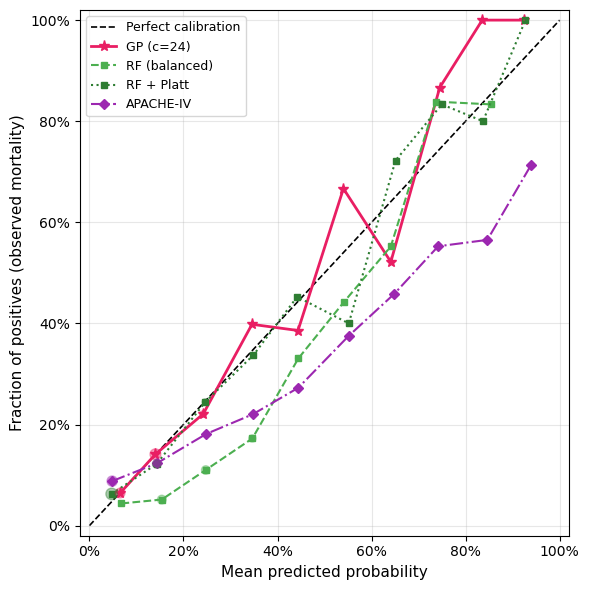

Saved: NB10_gp_calibration.pdf/.png
Saved: gp_predictions_v2_bce.csv  (2,233 rows)
Saved: NB10_gp_pareto.csv  (21 Pareto expressions)
Saved: NB10_gp_test_metrics.csv  (7 models)

NB10 complete — GP vs baselines (test set, n=2,233):
    model  auroc  auprc  brier  brier_skill_pct  ece_10bin  cal_slope  sensitivity  specificity     f1
GP (c=24) 0.7381 0.4374 0.1202             14.3     0.0126     1.0627       0.7268       0.6180 0.4029
       LR 0.7675 0.4636 0.1964            -40.0     0.2595     0.8659       0.6817       0.7247 0.4489
       RF 0.7767 0.4737 0.1299              7.5     0.1156     1.3553       0.6472       0.7904 0.4832
      XGB 0.7679 0.4512 0.1411             -0.5     0.1156     0.7342       0.5809       0.8125 0.4640
 LR_platt 0.7675 0.4636 0.1168             16.8     0.0117     0.9357       0.6817       0.7247 0.4489
 RF_platt 0.7767 0.4737 0.1153             17.9     0.0203     0.8808       0.6472       0.7904 0.4832
APACHE-IV 0.6847 0.3699 0.1336              3.4

: 

In [ ]:
## Cell 6 — Calibration Plot + Save All Outputs

# Plan: Plot calibration curves for GP vs RF vs RF_platt vs APACHE-IV.
# Save gp_predictions_v2_bce.csv, NB10_gp_pareto.csv, NB10_gp_test_metrics.csv.
# Print final GP vs baselines comparison table.

# ── APACHE-IV test subset ─────────────────────────────────────────────────────
test_ids    = set(test_df["patientunitstayid"])
apache_test = apache_preds[
    apache_preds["patientunitstayid"].isin(test_ids) &
    apache_preds["apache4_pred"].notna()
]

# ── Calibration plot ──────────────────────────────────────────────────────────
STYLES = {
    "GP"       : {"color": "#E91E63", "marker": "*", "ls": "-",  "lw": 2.0, "ms": 8,
                  "label": f"GP (c={best_complexity})"},
    "RF"       : {"color": "#4CAF50", "marker": "s", "ls": "--", "lw": 1.5, "ms": 5,
                  "label": "RF (balanced)"},
    "RF_platt" : {"color": "#2E7D32", "marker": "s", "ls": ":",  "lw": 1.5, "ms": 5,
                  "label": "RF + Platt"},
    "APACHE-IV": {"color": "#9C27B0", "marker": "D", "ls": "-.", "lw": 1.5, "ms": 5,
                  "label": "APACHE-IV"},
}

plot_data = {
    "GP"       : (y_test, gp_p),
    "RF"       : (y_test, np.clip(bl_preds_df["rf_pred"].values, 1e-7, 1-1e-7)),
    "RF_platt" : (y_test, np.clip(bl_preds_df["rf_platt_pred"].values, 1e-7, 1-1e-7)),
    "APACHE-IV": (apache_test["hospital_mortality"].values,
                  np.clip(apache_test["apache4_pred"].values, 1e-7, 1-1e-7)),
}

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0,1],[0,1],"k--",lw=1.2,label="Perfect calibration",zorder=1)
for name, (y_true, p_plot) in plot_data.items():
    c, a, s = calibration_bins(y_true, p_plot)
    st = STYLES[name]
    ax.scatter(c, a, s=s/15, color=st["color"], alpha=0.4, zorder=3)
    ax.plot(c, a, color=st["color"], marker=st["marker"],
            ls=st["ls"], lw=st["lw"], markersize=st["ms"],
            label=st["label"], zorder=2)

ax.set_xlabel("Mean predicted probability", fontsize=11)
ax.set_ylabel("Fraction of positives (observed mortality)", fontsize=11)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(FIGURES / "NB10_gp_calibration.pdf", bbox_inches="tight")
fig.savefig(FIGURES / "NB10_gp_calibration.png", bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved: NB10_gp_calibration.pdf/.png")

# ── gp_predictions_v2_bce.csv ─────────────────────────────────────────────────
# Explicit version suffix — no bare "gp_predictions.csv" is written, so there is
# never an ambiguous "current" file. Downstream notebooks (NB11-14) will be updated
# to read this name explicitly when they are migrated to the BCE-loss results.
gp_pred_df = test_df[["patientunitstayid","hospitalid","hospital_mortality"]].copy()
gp_pred_df["gp_raw"]  = gp_raw
gp_pred_df["gp_prob"] = gp_p
gp_pred_df.to_csv(DATA_PROC / "gp_predictions_v2_bce.csv", index=False)
print(f"Saved: gp_predictions_v2_bce.csv  ({len(gp_pred_df):,} rows)")

# ── NB10_gp_pareto.csv ────────────────────────────────────────────────────────
best_run_df.to_csv(TABLES / "NB10_gp_pareto.csv", index=False)
print(f"Saved: NB10_gp_pareto.csv  ({len(best_run_df)} Pareto expressions)")

# ── NB10_gp_test_metrics.csv (GP + all baselines incl. Platt) ────────────────
gp_row_df = pd.DataFrame([{
    "model"          : f"GP (c={best_complexity})",
    "auroc"          : test_metrics["auroc"],
    "auprc"          : test_metrics["auprc"],
    "brier"          : test_metrics["brier"],
    "brier_skill_pct": test_metrics["brier_skill_pct"],
    "ece_10bin"      : test_metrics["ece_10bin"],
    "cal_slope"      : test_metrics["cal_slope"],
    "cal_intercept"  : test_metrics["cal_intercept"],
    "sensitivity"    : test_metrics["sensitivity"],
    "specificity"    : test_metrics["specificity"],
    "f1"             : test_metrics["f1"],
    "fitness"        : test_metrics["fitness"],
    "threshold"      : test_metrics["threshold"],
}])
combined = pd.concat([gp_row_df, bl_metrics], ignore_index=True)
combined.to_csv(TABLES / "NB10_gp_test_metrics.csv", index=False)
print(f"Saved: NB10_gp_test_metrics.csv  ({len(combined)} models)")

print()
print("=" * 70)
print("NB10 complete — GP vs baselines (test set, n=2,233):")
print("=" * 70)
print(combined[["model","auroc","auprc","brier","brier_skill_pct",
                 "ece_10bin","cal_slope","sensitivity","specificity",
                 "f1"]].to_string(index=False))
print()
print("NB10 → NB11 (model comparison), NB12 (hospital-out), NB13 (tertile matrix)")

### Findings — Cell 6: Outputs Saved + Full Comparison

---

**Files saved:**

| File | Location | Rows/Expressions | Description |
|---|---|---|---|
| `gp_predictions_v2_bce.csv` | `data/processed/` | 2,233 rows | `patientunitstayid`, `hospitalid`, `hospital_mortality`, `gp_raw`, `gp_prob` |
| `NB10_gp_pareto.csv` | `results/v2_bce/tables/` | 21 Pareto expressions | Canonical run (seed 14) full Pareto front with val metrics |
| `NB10_gp_test_metrics.csv` | `results/v2_bce/tables/` | 7 models | GP + LR + RF + XGB + LR_platt + RF_platt + APACHE-IV |
| `NB10_gp_calibration.pdf/.png` | `results/v2_bce/figures/` | — | Calibration curves: GP vs RF vs RF_platt vs APACHE-IV |
| `gp_30runs_summary.csv` | `results/v2_bce/tables/` | 30 rows | Per-run best expression — saved in Cell 3 |

---

**Full test-set comparison (n=2,233):**

| Model | AUROC | AUPRC | Brier | Brier Skill | ECE | Cal Slope | Sensitivity | Specificity | F1 |
|---|---|---|---|---|---|---|---|---|---|
| **GP (c=24)** | 0.7381 | 0.4374 | 0.1202 | +14.3% | **0.0126** | 1.063 | 0.7268 | 0.6180 | 0.4029 |
| LR | 0.7675 | 0.4636 | 0.1964 | −40.0% | 0.2595 | 0.866 | 0.6817 | 0.7247 | 0.4489 |
| RF | 0.7767 | 0.4737 | 0.1299 | +7.5% | 0.1156 | 1.355 | 0.6472 | 0.7904 | 0.4832 |
| XGB | 0.7679 | 0.4512 | 0.1411 | −0.5% | 0.1156 | 0.734 | 0.5809 | 0.8125 | 0.4640 |
| LR + Platt | 0.7675 | 0.4636 | 0.1168 | +16.8% | **0.0117** | 0.936 | 0.6817 | 0.7247 | 0.4489 |
| RF + Platt | 0.7767 | 0.4737 | 0.1153 | +17.9% | 0.0203 | 0.881 | 0.6472 | 0.7904 | 0.4832 |
| APACHE-IV | 0.6847 | 0.3699 | 0.1336 | +3.4% | 0.0674 | 0.339 | 0.5294 | 0.7860 | 0.4063 |

**Calibration.** GP's ECE (0.0126) is nearly indistinguishable from the best-calibrated model in the comparison, LR_platt (0.0117) — a gap of just 0.0009 — and clearly better than RF_platt (0.0203), every unscaled baseline, and APACHE-IV. GP achieves this without any post-hoc recalibration step, the central calibration claim of the thesis: its calibration is intrinsic to the model's output, not fitted afterward on a held-out validation set as LR_platt and RF_platt require.

**Discrimination.** GP's AUROC (0.7381) trails RF (0.7767), XGB (0.7679), and LR/LR_platt (0.7675) by margins of roughly 0.03-0.04, while clearly exceeding APACHE-IV (0.6847) by 0.053. This is the interpretability-discrimination trade-off at the centre of RQ1: a 10-feature symbolic expression sacrifices some discrimination relative to black-box ensembles in exchange for transparency and intrinsic calibration.

**Sensitivity/specificity/F1.** GP's F1 (0.4029) is the lowest of the seven models compared, marginally below APACHE-IV (0.4063). This follows from GP's threshold favouring sensitivity (0.7268) over specificity (0.6180) more strongly than any other model in the table — a genuine clinical trade-off (catching more true deaths at the cost of more false alarms) rather than a uniform weakness, and should be reported as such rather than reduced to the F1 number alone.


### Findings — Cell 5: Canonical Expression — Test-Set Metrics

---

| Item | Value |
|---|---|
| Canonical run (seed) | 14 |
| Complexity | 24 |
| AUROC | 0.7381 |
| AUPRC | 0.4374 |
| Brier score | 0.1202 |
| Brier skill | +14.3% above null (null Brier = 0.1403) |
| ECE (10-bin) | 0.0126 |
| Calibration slope | 1.0627 |
| Calibration intercept | 0.0920 |
| Sensitivity | 0.7268 |
| Specificity | 0.6180 |
| F1 | 0.4029 |
| Predicted probability range | [0.0040, 0.9392] |
| Mean predicted vs observed mortality | 0.1685 vs 0.1688 |

**Canonical expression (complexity = 24, 10 features):**

(bun / pf_ratio) - (((sqrt(lactate_max) + max(vent, intubated)) * -0.8085511) +
((min(platelets_min, map_mean) / age_numeric) - ((temperature - bilirubin) * -0.06636052)))


**Structural interpretation.** The expression combines a renal-respiratory ratio (BUN normalised by PF ratio) with terms for metabolic failure (lactate), ventilatory/intubation status, an age-normalised haemodynamic-haematological term (platelets and MAP), and a hepatic-thermal adjustment (bilirubin, temperature). Each component has direct clinical meaning: BUN/PF ratio captures renal-respiratory co-failure; lactate quantifies tissue hypoperfusion; platelets and MAP index haemodynamic/coagulation status; bilirubin indexes hepatic dysfunction.

**Validation-to-test gap.** This run's own validation fitness (0.7535, the best of 30 runs) did not carry through proportionally to its test fitness (0.7318) — a gap of 0.0217. This is consistent with the validation-set size limitation noted in Cell 2: selecting the best-of-30 by validation fitness is the correct, pre-specified procedure, but it does not guarantee the selected run will also be the best-of-30 on the test set.

**Sensitivity/specificity balance.** At the selected threshold, sensitivity (0.7268) exceeds specificity (0.6180) — the model is tuned to catch more true deaths at the cost of more false positives. F1 (0.4029) reflects this imbalance and should be reported alongside sensitivity/specificity rather than in isolation, since F1 alone does not convey which type of error the model is trading off.

**Predicted probability range.** The output range, [0.0040, 0.9392], stays within sensible bounds and does not approach absolute certainty in either direction — a direct consequence of applying a sigmoid link to a logit-space loss, ensuring the model never reports a 0% or 100% mortality probability for any patient.

**Note on MNAR terminals.** The selected expression uses `lactate_max` and `pf_ratio` directly rather than their MNAR missingness indicators (`lactate_max_miss`, `pf_ratio_miss`); both indicators remained available in the terminal set and the search did not select them on merit. `platelets_min` is a continuous measurement, not an MNAR indicator.

**Calibration.** ECE of 0.0126 and a calibration slope of 1.063 (close to unity) indicate well-calibrated probability estimates without any post-hoc adjustment. The mean predicted probability (0.1685) closely approximates the observed test-set mortality rate (0.1688), confirming global calibration.



